In [2]:
import VMBQC_functions
from VMBQC_functions import *

In [3]:
torch.cuda.is_available()

True

In [4]:
# Hyperparameters

samples=8000 # Total number of samples from MBQC-CQCA 

target_samples = samples

qubits=7

depth=5

layers=depth

##  Learning models

In [5]:
# learning model in eq. 5 that can be adapted to models in equations 8,9,10,11 later based on the parameterization and gradient computation

dev = qml.device("default.mixed", wires=qubits,shots=target_samples)

@qml.qnode(dev)
def target_emodel(params):  
    
    p=params[:int(len(params)/2)] # probabilities
    
    t=params[len(p):] # thetas
    
    # Design of the fully corrected CQCA
    
    [qml.Hadamard(wires=q) for q in range(qubits)]
    

    for l in range(depth): 
        
        
        for q in range(qubits):
            qml.RZ(t[qubits*l+q],wires=q)
            
       
            
        
        for q in range(qubits):
            if q<qubits-1:
                qml.CZ(wires=[q,q+1])
        qml.CZ(wires=[0,qubits-1])  

        for q in range(qubits):
            qml.Hadamard(wires=q)

            qml.BitFlip((1-sigmoid(p[qubits*l+q]))/2,wires=q)
    
    return qml.sample()


In [8]:
def sample_circ(par): # sampling function that generates samples from the learning model

    binary_array = np.array(target_emodel(par))
    powers_of_two = 2 ** np.arange(binary_array.shape[1])[::-1]
    decimal_array = np.sum(binary_array * powers_of_two, axis=1)
    decimal_list = decimal_array.tolist()
    
    return decimal_list


### Loading the target distribution

In [8]:
#np.savetxt(f'target_dist_all',pg)
pg=np.loadtxt('target_dist_all')
pg

tensor([0.014   , 0.00625 , 0.007125, 0.00775 , 0.00925 , 0.014125,
        0.006625, 0.014125, 0.006125, 0.00875 , 0.005125, 0.00675 ,
        0.0085  , 0.005625, 0.0075  , 0.007625, 0.01    , 0.010125,
        0.00475 , 0.00825 , 0.0075  , 0.00525 , 0.007125, 0.007625,
        0.011   , 0.006   , 0.006625, 0.00575 , 0.00525 , 0.005   ,
        0.008125, 0.005125, 0.008875, 0.005375, 0.004875, 0.00475 ,
        0.008125, 0.008375, 0.008125, 0.008625, 0.00575 , 0.0065  ,
        0.007125, 0.004875, 0.006625, 0.0075  , 0.005875, 0.012625,
        0.00525 , 0.01275 , 0.008625, 0.00675 , 0.010375, 0.006625,
        0.006875, 0.010125, 0.01    , 0.01575 , 0.008125, 0.008125,
        0.008125, 0.00775 , 0.0055  , 0.00675 , 0.00525 , 0.0075  ,
        0.011   , 0.007875, 0.006125, 0.0065  , 0.010625, 0.006   ,
        0.00825 , 0.00575 , 0.008875, 0.007125, 0.01125 , 0.003625,
        0.00525 , 0.005875, 0.005125, 0.006   , 0.007125, 0.01075 ,
        0.00975 , 0.007125, 0.01075 , 0.00575 , 

In [9]:
# sampling from target distribution e.g. mixed gaussian
def sample_target_function():
    x=range(2**qubits)
    ret = np.random.choice(x,samples,p=pg)
    return ret.copy()

0.08558225631713867 sec


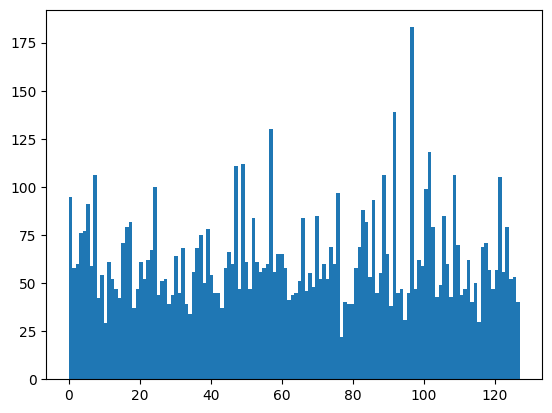

In [10]:
s=time.time()
opt_hist=plt.hist(sample_target_function(),bins=2**qubits)
e=time.time()
print(e-s,'sec')

In [11]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [12]:
# kernel function to calculate distance between two sample data points

def kernel_exp_torch(s1,s2):
    s1t = torch.tensor(s1, dtype = torch.float64).to(DEVICE)
    s2t = torch.tensor(s2, dtype = torch.float64).to(DEVICE)
    d1 = s1t.size(-1)
    d2 = s2t.size(-1)
    s1t = s1t.reshape([1,-1,1])
    s2t = s2t.reshape([1,-1,1])
    
    diffsquared = (torch.cdist(s1t,s2t,p=2.0).to(DEVICE))**2

    sigma_list=[0.5,4]
    exp = 0.0
    for sigma in sigma_list:
        expMatrix = torch.exp(diffsquared/(-2.0*sigma)).to(DEVICE)
        expMatrix = expMatrix/(len(sigma_list)*d1*d2)
        exp = exp + torch.sum(expMatrix).to(DEVICE)
        
    return exp

In [13]:
def mmd_loss(params):
    
    s2=sample_target_function()
    s1=sample_circ(params)
    res=kernel_exp_torch(s1,s1)-2*kernel_exp_torch(s1,s2)+kernel_exp_torch(s2,s2)
    return res.detach().cpu().numpy()


In [26]:
# Gradient for correction probability stated in eq. 13 of the manuscript for the model in Fig. 4(b) and 5(b)

def mmd_grad_p_new(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    grad = torch.zeros(len(p)).to(DEVICE)
    
    
    
    sample_targ=sample_target_function()
    
    for i in range(qubits): # only because the first layer has probabilistically corrected qubits and the rest are always corrected
        
        sample_y = sample_circ(params) ###############  
        
        a=p[i].copy()
        inner_derivative = (sigmoid(torch.tensor(a))**2)*torch.exp(-torch.tensor(a))
        
        p[i]=torch.tensor(100.0).numpy()
        
        sample_x_1 = sample_circ(params) ###############  
       
        
        p[i]=torch.tensor(-100.0).numpy()
        
        sample_x_0 = sample_circ(params) ###############  
        
        
        grad[i]=2*(kernel_exp_torch(sample_y,sample_x_1)-kernel_exp_torch(sample_y,sample_x_0)) - 2*(kernel_exp_torch(sample_targ,sample_x_1)-kernel_exp_torch(sample_targ,sample_x_0))
        grad[i]= grad[i]*inner_derivative
        p[i]=a
        
    return grad


def mmd_grad_1p(params):

    p_grad = mmd_grad_p_new(params)
        
    return torch.concatenate([torch.repeat_interleave(torch.sum(p_grad),qubits),torch.zeros(qubits*depth-qubits).to(DEVICE)])
    
    
# Gradient for variational parameters \thetas stated in eq. 16 of: https://arxiv.org/pdf/2310.13524.pdf
    
def mmd_grad_theta(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    prob = sample_circ(params)
    grad = torch.zeros(len(thetas)).to(DEVICE)
    
    for i in range(len(thetas)):
        # pi/2 phase
        thetas[i] += np.pi/2.
        prob_pos = sample_circ(params) # p_{theta}^{+}
        # -pi/2 phase
        thetas[i] -= np.pi
        prob_neg = sample_circ(params) # p_{theta}^{-}
        
        t1=kernel_exp_torch(prob, prob_pos)
        
        t2=kernel_exp_torch(prob, prob_neg)

        t3=kernel_exp_torch(sample_target_function(), prob_pos)
        
        t4=kernel_exp_torch(sample_target_function(), prob_neg)

        
        grad_pos = t1 - t2
        grad_neg = t3 - t4
        grad[i] = (grad_pos - grad_neg).detach().cpu()
        
        thetas[i] += np.pi/2.0 #reset to original value
        
    return grad


# combined gradient of both sets of parameters

def mmd_grad(params):
    
    grad=torch.cat((mmd_grad_1p(params),mmd_grad_theta(params)))
    return grad

In [28]:
#torch.cuda.empty_cache()

In [29]:
#import gc

#gc.collect()
#torch.cuda.empty_cache()


In [30]:
# algorithm for gradient descent copied from : https://docs.pennylane.ai/en/stable/code/api/pennylane.GradientDescentOptimizer.html

# We rewrote the algorithm with our approximate gradient calculated from samples instead of using the in-built exact gradient 

class GradientDescentOptimizer_mmd_2:  
    def __init__(self, stepsize): # if some value is given here itself then it will become a by default value
        self.stepsize = stepsize

    def step_and_cost(self, objective_fn, *args, grad_fn=None, **kwargs):
        
        g, forward = self.compute_grad(objective_fn, args, kwargs, grad_fn=grad_fn)
        new_args = self.apply_grad(g, args)

        if forward is None:
            forward = objective_fn(*args, **kwargs)

        # unwrap from list if one argument, cleaner return
        if len(new_args) == 1:
            return new_args[0], forward
        return new_args, forward


    def step(self, objective_fn, *args, train, grad_fn=None, **kwargs):
        
        p_len=int(len(args[0])/2)
        if train=='p':
            arg1=args[0][:int(len(args[0])/2)]
        else:
            arg1=args[0][int(len(args[0])/2):]
        
        g= self.compute_grad(objective_fn, args, kwargs, grad_fn=grad_fn)
        new_args = self.apply_grad(g, arg1,args,train)

        # unwrap from list if one argument, cleaner return
        if len(new_args) == 1:
            return new_args[0]

        return new_args

    @staticmethod
    def compute_grad(objective_fn, args, kwargs, grad_fn=None):
       
        
        grad = mmd_grad(*args).detach().cpu().numpy()
        

        num_trainable_args = sum(getattr(arg, "requires_grad", False) for arg in args)
        grad = (grad,) if num_trainable_args == 1 else grad
        #print('grads--',grad[0])
        return grad


    def apply_grad(self, grad, arg1,args,train):
        
        #print('arg1--',arg1)#################
        args_new = list(arg1)
        
        if train=='p':

            trained_index = 0
            for index, arg in enumerate(arg1):

                if getattr(arg, "requires_grad", False):
                    args_new[index] = arg - self.stepsize * grad[0][trained_index]

                    trained_index += 1
        else:
            trained_index = p_len ########## need to be generalized
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    args_new[index] = arg - self.stepsize * grad[0][trained_index]

                    trained_index += 1
            
        
        #print('new args-->',args_new[0])#############
        
        if train=='p':
            return np.concatenate([args_new,args[0][len(args_new):]])
        else:
            return np.concatenate([args[0][:len(args_new)],args_new]) # here we can do this only because the they have same size
        

In [31]:
# We use parts the above above algorithm to finally use the Adagrad optimization algorithm below to update our tunable parameters

from pennylane.numpy import sqrt
class AdagradOptimizer_mmd_2(GradientDescentOptimizer_mmd_2):
    

    def __init__(self, stepsize=0.01, eps=1e-8):
        super().__init__(stepsize)
        self.eps = eps
        self.accumulation = None

    def apply_grad(self, grad, arg1, args, train):
        
        p_len=int(len(args[0])/2)
        args_new = list(arg1)

        if self.accumulation is None:
            self.accumulation = [0.0] * len(arg1)
            
        if train=='p':

            trained_index = 0
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    

                    self._update_accumulation(index, grad[0][trained_index])

                    coeff = self.stepsize / sqrt(self.accumulation[index] + self.eps)
                    args_new[index] = arg - coeff * grad[0][trained_index]

                    trained_index += 1
                    
        else:
            
            trained_index = p_len # need to be generalized
            
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    

                    self._update_accumulation(index, grad[0][trained_index])

                    coeff = self.stepsize / sqrt(self.accumulation[index] + self.eps)
                    args_new[index] = arg - coeff * grad[0][trained_index]

                    trained_index += 1
            
            

        if train=='p':
            return np.concatenate([args_new,args[0][len(args_new):]])
        else:
            return np.concatenate([args[0][:len(args_new)],args_new])


    def _update_accumulation(self, index, grad):
        
        self.accumulation[index] = self.accumulation[index] + grad**2

    def reset(self):
        
        self.accumulation = None

In [32]:
def cost(par):

    c=mmd_loss(par) 
    return c

In [ ]:
runs_2=10
iterations=199  # next time if run the same experiment for more agents then iterations=199


## seeding 
import random
import os

# Set seed for reproducibility (before any random ops)
seed = 42
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
####### end of seeding



cost_arr=[]
params_arr=[]
for r in range(runs_2):
    opt1 = AdagradOptimizer_mmd_2(stepsize=0.2)
    opt2 = AdagradOptimizer_mmd_2(stepsize=0.1)

    k=range(qubits)
    p2=np.ones((qubits*depth))
    p2[k]=np.random.uniform(0.9,1,1) # This make sures that the first layer only gets 
    t2=np.random.uniform(0,2*np.pi,qubits*depth)
    init_p=np.concatenate([inv_sigmoid(p2),t2], requires_grad=True)
    params=init_p
    
    cost_arr.append(cost(init_p))
    params_arr.append(init_p)
    

    current_cost=[]
    
    for i in range(iterations):


        start=time.time()
        params = opt1.step(cost, params,train='p')
        params = opt2.step(cost, params,train='t')
        end=time.time()
        current_cost.append(cost(params))
        cost_arr.append(current_cost[i])
        

        params_arr.append(params)
        #params_arr_tot_2.append(params)

        if i % 1 == 0:
            print(f"Cost at step {i}:", current_cost[i],f'of run:{r}')

            
            print('time taken-->',(end-start)/60,'min')

    
        np.savetxt(f'layer_p/qubit:{qubits}_depth:{depth}_layer_p_loss_{r}.txt', cost_arr)
        np.savetxt(f'layer_p/qubit:{qubits}_depth:{depth}_layer_p_par_{r}.txt', params_arr)

Cost at step 0: 0.002587893253016265 of run:0
time taken--> 0.3579475522041321 min
Cost at step 1: 0.002285825204709817 of run:0
time taken--> 0.3616166273752848 min
Cost at step 2: 0.0019286190720643331 of run:0
time taken--> 0.355769944190979 min
Cost at step 3: 0.0015739245742840656 of run:0
time taken--> 0.3495657523473104 min
Cost at step 4: 0.0014492199702252212 of run:0
time taken--> 0.3521731416384379 min
Cost at step 5: 0.00137768337326577 of run:0
time taken--> 0.36398051182429 min
Cost at step 6: 0.0013118823840367333 of run:0
time taken--> 0.35412628650665284 min
Cost at step 7: 0.0012201008016036186 of run:0
time taken--> 0.3707945187886556 min
Cost at step 8: 0.0014901007239174272 of run:0
time taken--> 0.35057862599690753 min
Cost at step 9: 0.0011623335725811854 of run:0
time taken--> 0.35866300264994305 min
Cost at step 10: 0.001187675902601975 of run:0
time taken--> 0.3713886380195618 min
Cost at step 11: 0.0011344651995040152 of run:0
time taken--> 0.3606478850046793

In [43]:
min(cost_arr)

array(0.00038429)

In [40]:
sigmoid(params_arr[0][:qubits*depth]) # initial correction probabilities

tensor([0.93745401, 0.93745401, 0.93745401, 0.93745401, 0.93745401,
        0.93745401, 0.93745401, 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ], requires_grad=True)

In [41]:
sigmoid(params_arr[-1][:qubits*depth]) # correction probabilities at the end of the computation

tensor([0.84784847, 0.84784847, 0.84784847, 0.84784847, 0.84784847,
        0.84784847, 0.84784847, 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ], requires_grad=True)

In [272]:

import gc

mmd_grad(params).cpu()
del mmd_grad
gc.collect()
torch.cuda.empty_cache()
